# Exp2：基于回归分析的大学综合得分预测
---

## 一、案例简介
大学排名是一个非常重要同时也极富挑战性与争议性的问题，一所大学的综合实力涉及科研、师资、学生等方方面面。目前全球有上百家评估机构会评估大学的综合得分进行排序，而这些机构的打分也往往并不一致。在这些评分机构中，世界大学排名中心（Center for World University Rankings，缩写CWUR）以评估教育质量、校友就业、研究成果和引用，而非依赖于调查和大学所提交的数据著称，是非常有影响力的一个。

本任务中我们将根据 CWUR 所提供的世界各地知名大学各方面的排名（师资、科研等），一方面通过数据可视化的方式观察不同大学的特点，另一方面希望构建机器学习模型（线性回归）预测一所大学的综合得分。

## 二、作业说明
使用来自 Kaggle 的[数据](https://www.kaggle.com/mylesoneill/world-university-rankings?select=cwurData.csv)，构建「线性回归」模型，根据大学各项指标的排名预测综合得分。

**基本要求：**
* 按照 8:2 随机划分训练集测试集，用 RMSE 作为评价指标，得到测试集上线性回归模型的 RMSE 值；
* 对线性回归模型的系数进行分析。

**扩展要求：**
* 对数据进行观察与可视化，展示数据特点；
* 尝试其他的回归模型，对比效果；
* 尝试将离散的地区特征融入线性回归模型，并对结果进行对比。

**注意事项：**
* 基本输入特征有 8 个：`quality_of_education`, `alumni_employment`, `quality_of_faculty`, `publications`, `influence`, `citations`, `broad_impact`, `patents`；
* 预测目标为`score`；
* 可以使用 sklearn 等第三方库，不要求自己实现线性回归；
* 需要保留所有数据集生成、模型训练测试的代码；

## 三、数据概览

假设数据文件位于当前文件夹，我们用 pandas 读入标准 csv 格式文件的函数`read_csv()`将数据转换为`DataFrame`的形式。观察前几条数据记录：

In [173]:
import pandas as pd
import numpy as np

data_df = pd.read_csv('./cwurData.csv')  # 读入 csv 文件为 pandas 的 DataFrame
data_df.head(3).T  # 观察前几列并转置方便观察

,0,1,2
world_rank,1,2,3
institution,Harvard University,Massachusetts Institute of Technology,Stanford University
region,USA,USA,USA
national_rank,1,2,3
quality_of_education,7,9,17
alumni_employment,9,17,11
quality_of_faculty,1,3,5
publications,1,12,4
influence,1,4,2
citations,1,4,2


去除其中包含 NaN 的数据，保留 2000 条有效记录。

In [174]:
data_df = data_df.dropna()  # 舍去包含 NaN 的 row
len(data_df)

2000

取出对应自变量以及因变量的列，之后就可以基于此切分训练集和测试集，并进行模型构建与分析。

In [175]:
feature_cols = ['quality_of_faculty', 'publications', 'citations', 'alumni_employment', 
                'influence', 'quality_of_education', 'broad_impact', 'patents']
X = data_df[feature_cols]
Y = data_df['score']
X

,quality_of_faculty,publications,citations,alumni_employment,influence,quality_of_education,broad_impact,patents
200,1,1,1,1,1,1,1.0,2
201,4,5,3,2,3,11,4.0,6
202,2,15,2,11,2,3,2.0,1
203,5,10,12,10,9,2,13.0,48
204,10,11,11,12,12,7,12.0,16
...,...,...,...,...,...,...,...,...
2195,218,926,812,567,845,367,969.0,816
2196,218,997,645,566,908,236,981.0,871
2197,218,830,812,549,823,367,975.0,824
2198,218,886,812,567,974,367,975.0,651


## 四、模型构建

### 4.1 基本要求1——线性回归模型
按照 8:2 随机划分训练集测试集，构建线性回归模型，用 RMSE 作为评价指标。

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

RANDOM_SEED = 100

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_SEED)

print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

Y_pred_lr = lr_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(Y_test, Y_pred_lr))
print(f"RMSE: {rmse_lr}")

训练集大小: 1600
测试集大小: 400
RMSE: 4.248950093163294


### 4.2 基本要求2——对线性回归模型的系数进行分析

线性回归模型系数：
                  特征        系数
  quality_of_faculty -0.061444
        publications  0.000450
           citations -0.000283
   alumni_employment -0.006612
           influence  0.000718
quality_of_education -0.007044
        broad_impact -0.002532
             patents -0.002521
截距：65.4177091793342


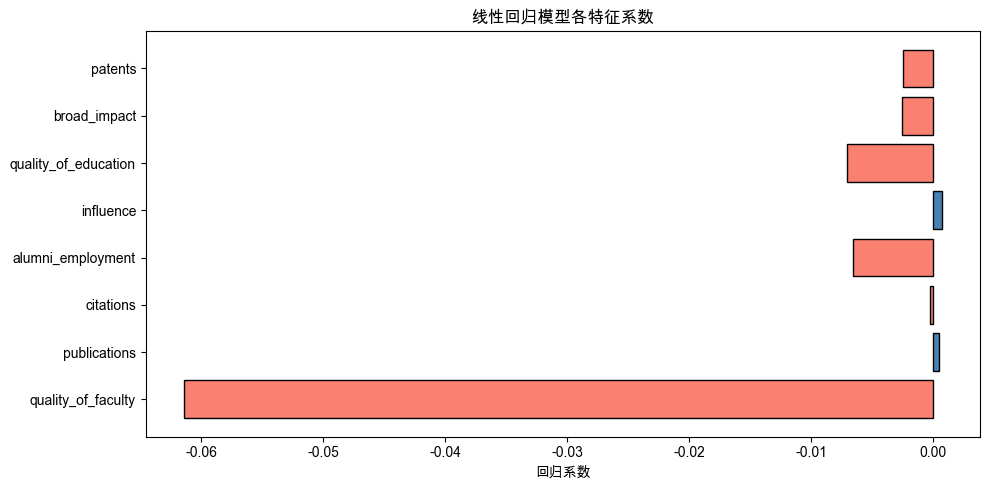


系数分析：
- 绝对值越大的特征对综合得分的影响越显著。


In [177]:
# 输出线性回归模型的系数
coef_df = pd.DataFrame({
    '特征': feature_cols,
    '系数': list(lr_model.coef_),
})
print("线性回归模型系数：")
print(coef_df.to_string(index=False))
print(f"截距：{lr_model.intercept_}")

# 可视化系数
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c >= 0 else 'salmon' for c in coef_df['系数']]
plt.barh(coef_df['特征'], coef_df['系数'], color=colors, edgecolor='black')
plt.xlabel('回归系数')
plt.title('线性回归模型各特征系数')
plt.tight_layout()
plt.show()

print("\n系数分析：")
print("- 绝对值越大的特征对综合得分的影响越显著。")

## 五、扩展要求1——对数据进行观察与可视化，展示数据特点

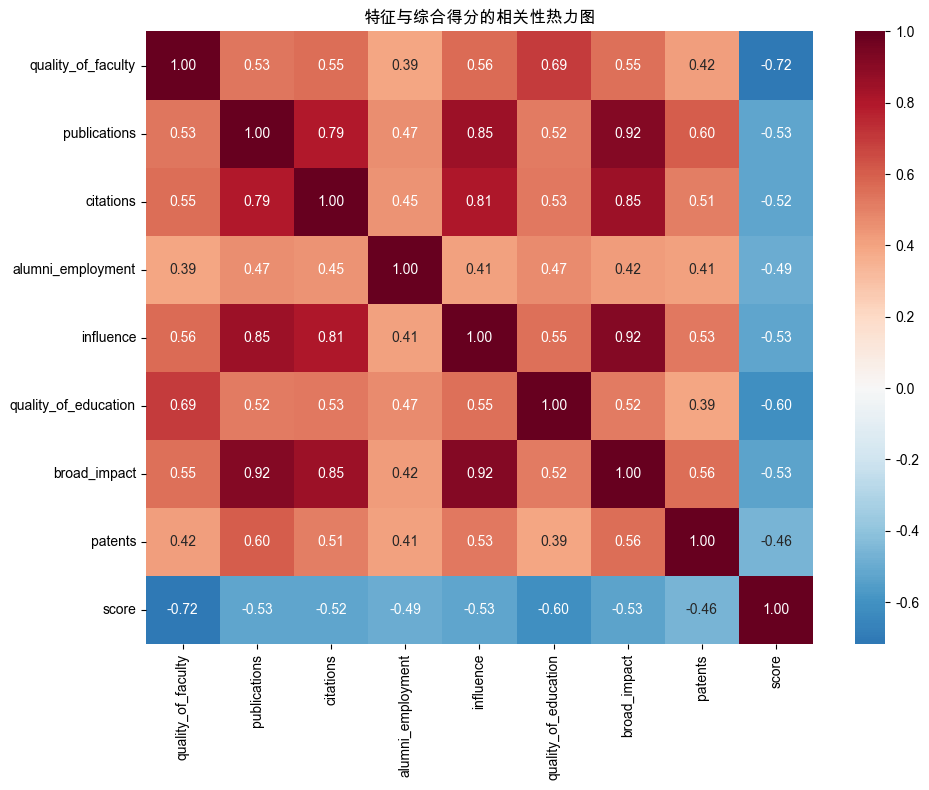

In [178]:
# 1. 各特征与综合得分的相关性热力图
plt.figure(figsize=(10, 8))
corr_cols = feature_cols + ['score']
corr_matrix = data_df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('特征与综合得分的相关性热力图')
plt.tight_layout()
plt.show()

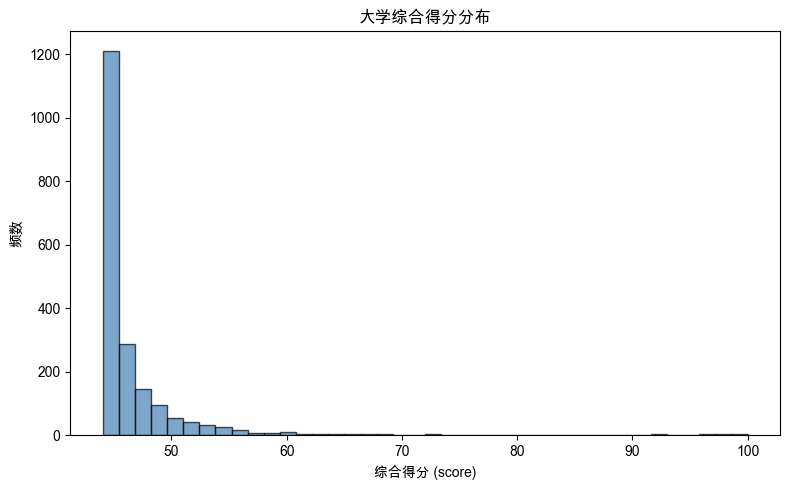

In [179]:
# 2. 综合得分分布
plt.figure(figsize=(8, 5))
plt.hist(data_df['score'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('综合得分 (score)')
plt.ylabel('频数')
plt.title('大学综合得分分布')
plt.tight_layout()
plt.show()

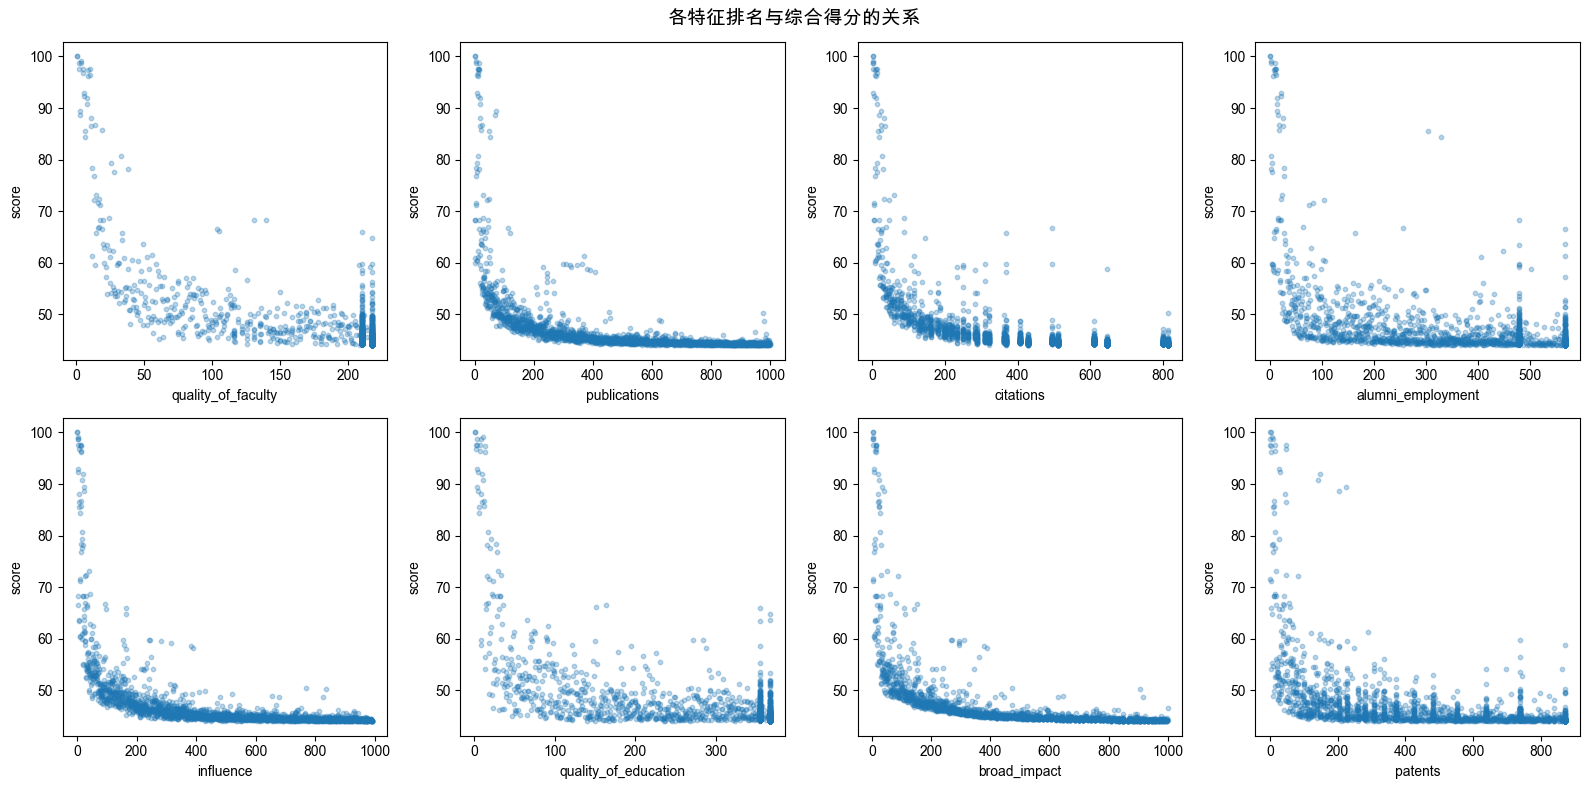

In [180]:
# 3. 各特征与综合得分的散点图
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, col in enumerate(feature_cols):
    ax = axes[idx // 4, idx % 4]
    ax.scatter(data_df[col], data_df['score'], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel('score')
plt.suptitle('各特征排名与综合得分的关系', fontsize=14)
plt.tight_layout()
plt.show()

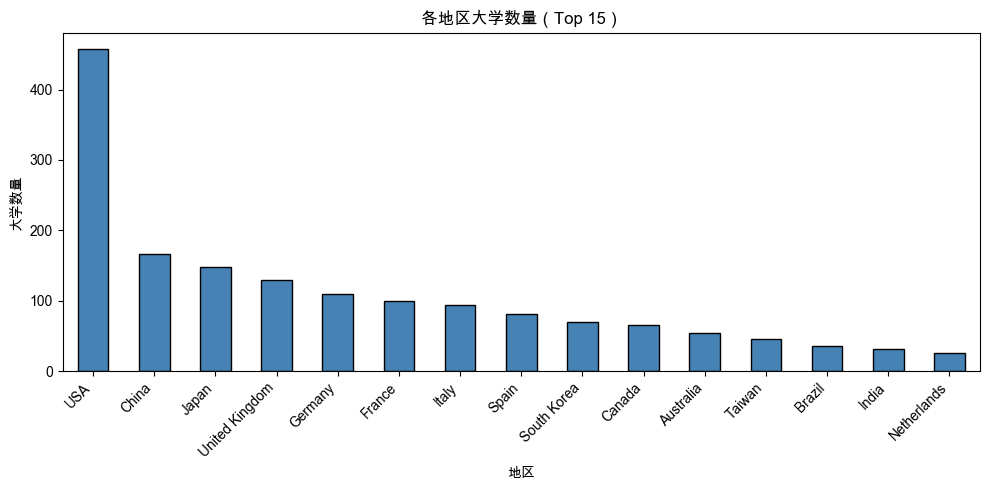

In [181]:
# 4. 不同地区大学数量统计（Top 15）
region_counts = data_df['region'].value_counts().head(15)
plt.figure(figsize=(10, 5))
region_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('地区')
plt.ylabel('大学数量')
plt.title('各地区大学数量（Top 15）')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 六、扩展要求2——尝试其他的回归模型，对比效果

线性回归 测试集 RMSE: 4.2490
岭回归 (Ridge) 测试集 RMSE: 4.2490
Lasso 回归 测试集 RMSE: 4.2490


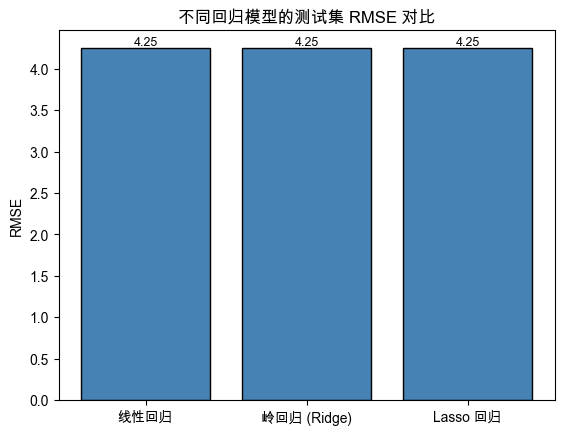

In [182]:
from sklearn.linear_model import Ridge, Lasso

models = {
    '线性回归': LinearRegression(),
    '岭回归 (Ridge)': Ridge(alpha=1.0),
    'Lasso 回归': Lasso(alpha=0.1),
}

results = {}
for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
    results[name] = rmse
    print(f"{name} 测试集 RMSE: {rmse:.4f}")

# 可视化对比
model_names = list(results.keys())
rmse_values = list(results.values())
bars = plt.bar(model_names, rmse_values, color='steelblue', edgecolor='black')
plt.ylabel('RMSE')
plt.title('不同回归模型的测试集 RMSE 对比')
for bar, val in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.show()

## 七、扩展要求3——将离散的地区特征融入线性回归模型，并对结果进行对比

不含地区特征的线性回归 RMSE: 4.2490
含地区特征的线性回归 RMSE:   4.1693

融入地区特征后，RMSE 降低了 0.0797，说明地区信息对预测综合得分有一定帮助。


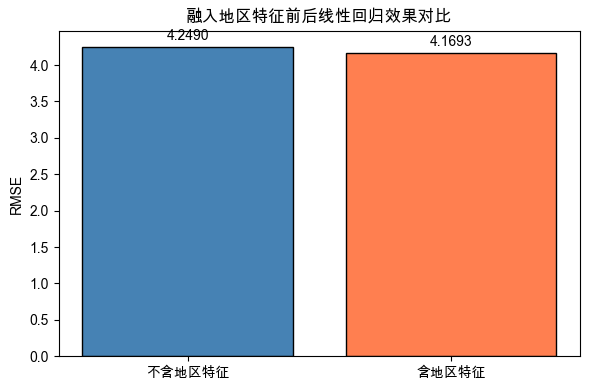

In [183]:
# 对地区进行 One-Hot 编码
region_dummies = pd.get_dummies(data_df['region'], prefix='region')

# 将地区特征与原始特征拼接
X_with_region = pd.concat([X, region_dummies], axis=1)

# 划分训练集和测试集（使用相同的 random_state 保证可比性）
X_train_r, X_test_r, Y_train_r, Y_test_r = train_test_split(
    X_with_region, Y, test_size=0.2, random_state=RANDOM_SEED
)

# 训练线性回归模型（含地区特征）
lr_model_region = LinearRegression()
lr_model_region.fit(X_train_r, Y_train_r)
Y_pred_region = lr_model_region.predict(X_test_r)
rmse_region = np.sqrt(mean_squared_error(Y_test_r, Y_pred_region))

print(f"不含地区特征的线性回归 RMSE: {rmse_lr:.4f}")
print(f"含地区特征的线性回归 RMSE:   {rmse_region:.4f}")

if rmse_region < rmse_lr:
    print(f"\n融入地区特征后，RMSE 降低了 {rmse_lr - rmse_region:.4f}，说明地区信息对预测综合得分有一定帮助。")
else:
    print(f"\n融入地区特征后，RMSE 增加了 {rmse_region - rmse_lr:.4f}，可能是因为 One-Hot 编码引入了过多特征导致过拟合。")

# 对比柱状图
plt.figure(figsize=(6, 4))
labels = ['不含地区特征', '含地区特征']
values = [rmse_lr, rmse_region]
bars = plt.bar(labels, values, color=['steelblue', 'coral'], edgecolor='black')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.ylabel('RMSE')
plt.title('融入地区特征前后线性回归效果对比')
plt.tight_layout()
plt.show()